# 02_text_eda_refined

이 노트북은 `02_text_eda_baseline.ipynb`의 결과를 바탕으로,  
텍스트 전처리와 해석 가능성을 한 단계 보완한 **refined 버전**이다.

## baseline과 refined의 차이

### 1. baseline의 목적
`02_text_eda_baseline.ipynb`는 전처리된 리뷰 데이터를 바탕으로 다음을 빠르게 확인하는 데 목적이 있었다.

- 전체 리뷰 수 및 기본 분포
- 날짜별 리뷰 수 / 긍정 비율 / 평균 길이 추이
- 리뷰 길이 분석
- 단어 빈도 / TF-IDF / n-gram
- 긍정/부정 리뷰 키워드 비교
- 샘플 기반 토픽 탐색

즉, baseline은 **데이터의 전체 흐름을 가볍고 안정적으로 파악하는 기초 EDA**에 해당한다.

### 2. refined의 목적
반면 이 노트북은 baseline 결과를 검토한 뒤 드러난 한계를 보완하는 데 목적이 있다.

예를 들어 baseline에서는 다음과 같은 점이 확인되었다.

- `연기`, `연기가`, `연기는`처럼 비슷한 표현이 분리되어 집계됨
- `좋았어요`, `좋았고`, `좋았다`처럼 활용형이 흩어져 나타남
- `&lt;`, `&gt;`, `\n` 같은 HTML escape 및 줄바꿈 노이즈가 일부 존재함
- 지나치게 짧은 리뷰가 키워드 분석의 해석력을 떨어뜨릴 수 있음
- 후반부 긍정 비율 하락이라는 흥미로운 패턴이 보였으나, 시기 구간 비교는 아직 충분하지 않았음

따라서 refined 버전에서는 다음을 추가로 수행한다.

- HTML escape 및 줄바꿈 정리
- 자주 등장하는 핵심 단어의 규칙 기반 통합
- 불용어 보완
- 너무 짧은 리뷰를 제외한 텍스트 분석 버전 추가
- 시기 구간(초반/중반/후반) 비교 분석
- baseline보다 해석력 있는 키워드 / TF-IDF / n-gram 결과 도출

즉, refined는 **EDA의 안정성을 유지하면서도 텍스트 분석의 해석력을 높이기 위한 보완 단계**이다.

## 이 노트북의 주요 분석 내용

- refined 전처리
- baseline 대비 텍스트 정제 개선
- 짧은 리뷰 제외 버전 분석
- 구간별(초반/중반/후반) 비교
- refined 키워드 빈도 / TF-IDF / n-gram
- 긍정/부정 키워드 재비교
- 샘플 기반 토픽 탐색 보완

# 02_text_eda_refined

이 노트북은 `02_text_eda_baseline.ipynb`의 결과를 바탕으로,  
텍스트 전처리와 해석 가능성을 한 단계 보완한 **refined 버전**이다.

## baseline과 refined의 차이

### 1. baseline의 목적
`02_text_eda_baseline.ipynb`는 전처리된 리뷰 데이터를 바탕으로 다음을 빠르게 확인하는 데 목적이 있었다.

- 전체 리뷰 수 및 기본 분포
- 날짜별 리뷰 수 / 긍정 비율 / 평균 길이 추이
- 리뷰 길이 분석
- 단어 빈도 / TF-IDF / n-gram
- 긍정/부정 리뷰 키워드 비교
- 샘플 기반 토픽 탐색

즉, baseline은 **데이터의 전체 흐름을 가볍고 안정적으로 파악하는 기초 EDA**에 해당한다.

### 2. refined의 목적
반면 이 노트북은 baseline 결과를 검토한 뒤 드러난 한계를 보완하는 데 목적이 있다.

예를 들어 baseline에서는 다음과 같은 점이 확인되었다.

- `연기`, `연기가`, `연기는`처럼 비슷한 표현이 분리되어 집계됨
- `좋았어요`, `좋았고`, `좋았다`처럼 활용형이 흩어져 나타남
- `&lt;`, `&gt;`, `\n` 같은 HTML escape 및 줄바꿈 노이즈가 일부 존재함
- 지나치게 짧은 리뷰가 키워드 분석의 해석력을 떨어뜨릴 수 있음
- 후반부 긍정 비율 하락이라는 흥미로운 패턴이 보였으나, 시기 구간 비교는 아직 충분하지 않았음

따라서 refined 버전에서는 다음을 추가로 수행한다.

- HTML escape 및 줄바꿈 정리
- 자주 등장하는 핵심 단어의 규칙 기반 통합
- 불용어 보완
- 너무 짧은 리뷰를 제외한 텍스트 분석 버전 추가
- 시기 구간(초반/중반/후반) 비교 분석
- baseline보다 해석력 있는 키워드 / TF-IDF / n-gram 결과 도출

즉, refined는 **EDA의 안정성을 유지하면서도 텍스트 분석의 해석력을 높이기 위한 보완 단계**이다.

## 이 노트북의 주요 분석 내용

- refined 전처리
- baseline 대비 텍스트 정제 개선
- 짧은 리뷰 제외 버전 분석
- 구간별(초반/중반/후반) 비교
- refined 키워드 빈도 / TF-IDF / n-gram
- 긍정/부정 키워드 재비교
- 샘플 기반 토픽 탐색 보완

In [1]:
from pathlib import Path
import sys
import re
import html
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [2]:
# 출력 옵션
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 300)

# matplotlib 한글 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

## 1. 프로젝트 경로 설정

이 노트북은 `cgv_review_project/notebooks/` 안에 위치한다고 가정한다.  
따라서 현재 작업 디렉토리가 `notebooks`라면, 그 상위 폴더를 프로젝트 루트로 설정한다.

이후 `data/processed/`의 전처리 결과를 불러오고,  
`outputs/figures/`, `outputs/tables/`에 refined 결과를 저장한다.

In [3]:
CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
elif (CURRENT_DIR / "data").exists() and (CURRENT_DIR / "outputs").exists():
    PROJECT_ROOT = CURRENT_DIR
else:
    raise FileNotFoundError(
        "프로젝트 루트를 찾지 못했습니다. "
        "노트북을 cgv_review_project 또는 cgv_review_project/notebooks 기준으로 실행해주세요."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

PROCESSED_TEXT_PATH = PROJECT_ROOT / "data" / "processed" / "reviews_cleaned_text.csv"
PROCESSED_TIME_PATH = PROJECT_ROOT / "data" / "processed" / "reviews_cleaned_time.csv"

FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("CURRENT_DIR :", CURRENT_DIR)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("FIGURE_DIR  :", FIGURE_DIR)
print("TABLE_DIR   :", TABLE_DIR)
print("FIGURE_DIR exists?:", FIGURE_DIR.exists())
print("TABLE_DIR exists?:", TABLE_DIR.exists())

CURRENT_DIR : C:\Users\USER\Desktop\cgv_review_project\notebooks
PROJECT_ROOT: C:\Users\USER\Desktop\cgv_review_project
FIGURE_DIR  : C:\Users\USER\Desktop\cgv_review_project\outputs\figures
TABLE_DIR   : C:\Users\USER\Desktop\cgv_review_project\outputs\tables
FIGURE_DIR exists?: True
TABLE_DIR exists?: True


In [4]:
def save_current_figure(filename: str, figure_dir: Path = FIGURE_DIR, dpi: int = 150) -> Path:
    """
    현재 matplotlib figure를 지정한 폴더에 저장하고 경로를 반환한다.
    """
    figure_dir.mkdir(parents=True, exist_ok=True)
    save_path = figure_dir / filename
    plt.tight_layout()
    plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
    print(f"저장 완료: {save_path}")
    return save_path

## 2. 전처리 데이터 불러오기

baseline과 동일하게 `clean_reviews.py`의 결과 파일을 사용한다.

- `df_text` : 전체 텍스트 분석용
- `df_time` : 부분 수집일 제외 시계열 분석용

refined 버전에서는 이 데이터를 다시 가공하여,  
텍스트 정제 수준을 높인 별도 컬럼을 생성해 분석에 사용한다.

In [5]:
df_text = pd.read_csv(PROCESSED_TEXT_PATH)
df_time = pd.read_csv(PROCESSED_TIME_PATH)

print("df_text shape:", df_text.shape)
print("df_time shape:", df_time.shape)

df_text shape: (46599, 27)
df_time shape: (46596, 27)


## 3. baseline 대비 refined 전처리 전략

이 단계에서는 baseline보다 조금 더 정교한 텍스트 정제를 수행한다.

주요 보완 내용은 다음과 같다.

- HTML escape 해제
- 줄바꿈 문자 제거
- 반복 공백 정리
- 웃음/눈물 표현 반복 축약
- 자주 등장하는 핵심 단어의 규칙 기반 통합
- 불용어 보완

이 방식은 형태소 분석기 수준의 정교함은 아니지만,  
현재 8GB 환경에서 무리 없이 실행 가능하면서도  
키워드, TF-IDF, n-gram의 해석력을 높이는 데 효과적이다.

In [6]:
STOPWORDS_PATH = PROJECT_ROOT / "data" / "external" / "stopwords_ko.txt"

if STOPWORDS_PATH.exists():
    with open(STOPWORDS_PATH, "r", encoding="utf-8") as f:
        stopwords_ko = {line.strip() for line in f if line.strip()}
else:
    stopwords_ko = set()

# baseline보다 보완된 공통 불용어
basic_stopwords = {
    "영화", "진짜", "정말", "너무", "그냥", "약간", "좀", "아주",
    "이거", "이건", "그거", "그건", "저는", "제가", "나는", "내가",
    "보고", "봤다", "봤는데", "봤고", "봤어요", "보는", "보니",
    "근데", "그리고", "그래서", "하지만", "또한", "정도", "느낌",
    "같다", "같아요", "같음", "같은", "하는", "있는", "없는",
    "하다", "했다", "합니다", "입니다", "있다", "없다",
    "에서", "으로", "에게", "까지", "부터", "이라", "이라서",
    "그리고요", "그런데", "이렇게", "저렇게", "하는데", "하면서"
}

# 분석 목적에 따라 제외를 고민할 수 있는 단어들
# 현재 refined에서는 전체 주제 파악력을 위해 일부는 유지한다.
optional_stopwords = {
    "좋았어요", "좋다", "재밌다"
}

stopwords = stopwords_ko | basic_stopwords | optional_stopwords

print("stopwords 개수:", len(stopwords))

stopwords 개수: 59


In [7]:
# 자주 반복되는 핵심 단어를 규칙 기반으로 통합
REPLACEMENTS = {
    "연기가": "연기",
    "연기는": "연기",
    "연기를": "연기",
    "연기만": "연기",
    "배우들의": "배우",
    "배우들": "배우",
    "배우님": "배우",
    "좋았어요": "좋다",
    "좋았고": "좋다",
    "좋았다": "좋다",
    "좋았음": "좋다",
    "재밌게": "재밌다",
    "재밌어요": "재밌다",
    "재밌었다": "재밌다",
    "재밌고": "재밌다",
    "슬펐어요": "슬프다",
    "슬펐다": "슬프다",
    "감동적이었어요": "감동적",
    "감동적이었다": "감동적",
    "여운이": "여운",
    "눈물이": "눈물",
}

In [8]:
def normalize_text_refined(text: str) -> str:
    text = str(text)

    # HTML escape 해제
    text = html.unescape(text)

    # 줄바꿈 / 탭 정리
    text = text.replace("\n", " ").replace("\r", " ").replace("\t", " ")

    # 소문자 변환
    text = text.lower()

    # 반복 웃음/눈물 표현 약간 정리
    text = re.sub(r"ㅋ{3,}", "ㅋㅋ", text)
    text = re.sub(r"ㅎ{3,}", "ㅎㅎ", text)
    text = re.sub(r"ㅠ{3,}", "ㅠㅠ", text)

    # 숫자 제거
    text = re.sub(r"[0-9]+", " ", text)

    # 한글, 영문, 공백만 남기기
    text = re.sub(r"[^가-힣a-z\s]", " ", text)

    # 공백 정리
    text = re.sub(r"\s+", " ", text).strip()

    return text


def apply_replacements(text: str, replacements: dict[str, str]) -> str:
    tokens = text.split()
    tokens = [replacements.get(tok, tok) for tok in tokens]
    return " ".join(tokens)


df_text["review_normalized_refined"] = (
    df_text["review"]
    .astype(str)
    .apply(normalize_text_refined)
    .apply(lambda x: apply_replacements(x, REPLACEMENTS))
)

df_time["review_normalized_refined"] = (
    df_time["review"]
    .astype(str)
    .apply(normalize_text_refined)
    .apply(lambda x: apply_replacements(x, REPLACEMENTS))
)

df_text[["review", "review_normalized_refined"]].head(10)

,review,review_normalized_refined
0,기대하고 봤는데 기대한 만큼 좋았음 마지막이 아쉬웠는데\n스토리 특성상 원래 있던 내용을 기본으로 깔고가는거라 \n이해됐음ㅁㅁ,기대하고 봤는데 기대한 만큼 좋다 마지막이 아쉬웠는데 스토리 특성상 원래 있던 내용을 기본으로 깔고가는거라 이해됐음
1,많이 울고 많이 웃었습니다.\n마음이 너무 짠한영화,많이 울고 많이 웃었습니다 마음이 너무 짠한영화
2,특히 마지막 단종의삶을 그대로 표현해낸\n배우들의 연기에 몰입하고 왕의 자리의 힘듬을 잘 그려낸영화입니다,특히 마지막 단종의삶을 그대로 표현해낸 배우 연기에 몰입하고 왕의 자리의 힘듬을 잘 그려낸영화입니다
3,박지훈의 무게감 있는 왕 연기 최고였고 유해진님과의 케미도 너무 좋아서 재밌고 감동깊게 잘 봤습니다\n좋은 작품 보여주셔서 감사합니다,박지훈의 무게감 있는 왕 연기 최고였고 유해진님과의 케미도 너무 좋아서 재밌다 감동깊게 잘 봤습니다 좋은 작품 보여주셔서 감사합니다
4,단종과 '엄흥도'의 이야기를 이렇게 풀어냈다는게 참 대단하다는 생각이든다.\n다만 나와 영화의 깊이와 속도가 맞지않아 조금 아쉬웠고 이렇게이렇게 흥행한다고? 싶은 생각도 들었다,단종과 엄흥도 의 이야기를 이렇게 풀어냈다는게 참 대단하다는 생각이든다 다만 나와 영화의 깊이와 속도가 맞지않아 조금 아쉬웠고 이렇게이렇게 흥행한다고 싶은 생각도 들었다
5,너무 스토리를 다 알아서 그런지 저는 소소,너무 스토리를 다 알아서 그런지 저는 소소
6,단종의 생애가 슬펏지만\n전반적인 서사를 느낄 수 있어서 좋았습니다.,단종의 생애가 슬펏지만 전반적인 서사를 느낄 수 있어서 좋았습니다
7,늦게 봤지만 알고 봤지만 계속 눈물이 나는 영화\n어린 임금이지만 마음은 얼마나 깊고 따스한지\n지금도 어디엔가 있을 것만 같은 따뜻한 사람들에게 위로가 되는 영화 참 좋았다.,늦게 봤지만 알고 봤지만 계속 눈물 나는 영화 어린 임금이지만 마음은 얼마나 깊고 따스한지 지금도 어디엔가 있을 것만 같은 따뜻한 사람들에게 위로가 되는 영화 참 좋다
8,볼만했어요. 강추까지는..,볼만했어요 강추까지는
9,"친정엄마, 시어머니께 효도 한방했네요. 영화보여줘 두분다 좋았다 고맙다하시네요.\n유지태, 유해진, 박지훈, 지방관리, 상긍 등 연기 짱이네요.\n장항준 검독님은 진짜 복도 많으시네요.\n🐒🐎",친정엄마 시어머니께 효도 한방했네요 영화보여줘 두분다 좋다 고맙다하시네요 유지태 유해진 박지훈 지방관리 상긍 등 연기 짱이네요 장항준 검독님은 진짜 복도 많으시네요


## 4. 너무 짧은 리뷰 제외 버전 만들기

짧은 리뷰는 전체 감성 흐름을 보는 데는 유용하지만,  
키워드·TF-IDF·n-gram 같은 주제 분석에서는 노이즈가 될 수 있다.

따라서 refined에서는 분석용 서브셋을 하나 더 만든다.

- `df_text` : 전체 리뷰 유지
- `df_text_sub` : 일정 길이 이상 리뷰만 사용

여기서는 우선 `review_length >= 10` 기준을 적용한다.  
이 기준은 너무 엄격하지 않으면서도  
짧은 감탄형/반복형 리뷰를 어느 정도 걸러낼 수 있다.

In [9]:
MIN_REVIEW_LENGTH = 10

df_text_sub = df_text[df_text["review_length"] >= MIN_REVIEW_LENGTH].copy()
df_time_sub = df_time[df_time["review_length"] >= MIN_REVIEW_LENGTH].copy()

print("전체 df_text:", df_text.shape)
print("길이 필터 적용 df_text_sub:", df_text_sub.shape)
print("전체 df_time:", df_time.shape)
print("길이 필터 적용 df_time_sub:", df_time_sub.shape)

전체 df_text: (46599, 28)
길이 필터 적용 df_text_sub: (46410, 28)
전체 df_time: (46596, 28)
길이 필터 적용 df_time_sub: (46407, 28)


## 5. baseline과 refined 텍스트 예시 비교

정규화 및 규칙 기반 치환이 실제로 어떤 효과를 내는지  
몇 개의 샘플을 통해 확인한다.

이 단계는 결과 해석 전에 텍스트 정제 품질을 눈으로 점검하는 과정이다.

In [10]:
sample_compare = df_text[["review", "review_normalized_refined"]].sample(10, random_state=42).reset_index(drop=True)
sample_compare

,review,review_normalized_refined
0,영화 10번 보면 세 번 쯤은 금성대군이랑 만나고\n한 번 쯤은 단종 복위 성공하지 않을까요🚬\n#박지훈,영화 번 보면 세 번 쯤은 금성대군이랑 만나고 한 번 쯤은 단종 복위 성공하지 않을까요 박지훈
1,긴 연휴라 오랜만에 영화관 방문..\n뻔한 역사적 사실에 msg 조금 뿌리니 아주 기가 막히네요..\n몰랐던 사실도 있고 유해진의 뻔한 연기는 유해진만 가능할듯..,긴 연휴라 오랜만에 영화관 방문 뻔한 역사적 사실에 msg 조금 뿌리니 아주 기가 막히네요 몰랐던 사실도 있고 유해진의 뻔한 연기 유해진만 가능할듯
2,나쁘지 않았습니다.,나쁘지 않았습니다
3,3월초 휴일을 계기로 천만관객에 한걸음 더 다가가길 기원합니다. 파이팅!,월초 휴일을 계기로 천만관객에 한걸음 더 다가가길 기원합니다 파이팅
4,유해진 연기는 역시 좋네요,유해진 연기 역시 좋네요
5,"감정적인 상상력을 30퍼센트만 덜어냈어도, 배우들의 호연이 아깝지 않았을텐데",감정적인 상상력을 퍼센트만 덜어냈어도 배우 호연이 아깝지 않았을텐데
6,마음 아픈 역사를 재조명 해 주신 감독님과 한 배역 한 배역 배우들의 연기가 너무 멋있습니다 이 영화를 통해 역사를 공부하고 싶은 마음이 간절히 생기게 되었습니다 감동입니다! 강추입니다! 천만영화~기대,마음 아픈 역사를 재조명 해 주신 감독님과 한 배역 한 배역 배우 연기 너무 멋있습니다 이 영화를 통해 역사를 공부하고 싶은 마음이 간절히 생기게 되었습니다 감동입니다 강추입니다 천만영화 기대
7,너무 재밌었어요 중간에 움 ㅠㅠ,너무 재밌었어요 중간에 움
8,유해진님 연기 최고입니다,유해진님 연기 최고입니다
9,결말은 알지만 여운이 남네요,결말은 알지만 여운 남네요


## 6. 시기 구간 변수 생성

baseline에서 후반부 긍정 비율 하락이 관찰되었기 때문에,  
이번에는 시기를 구간으로 나누어 비교한다.

구간은 다음과 같이 설정한다.

- 초반: 2026-02-07 ~ 2026-02-20
- 중반: 2026-02-21 ~ 2026-03-10
- 후반: 2026-03-11 ~ 2026-03-29

이 구간 구분은 관객 반응의 흐름을 보다 서술적으로 해석하기 위한 목적이다.

In [11]:
df_text["review_date_dt"] = pd.to_datetime(df_text["review_date"])
df_time["review_date_dt"] = pd.to_datetime(df_time["review_date"])

def assign_period(dt):
    if pd.Timestamp("2026-02-07") <= dt <= pd.Timestamp("2026-02-20"):
        return "초반"
    elif pd.Timestamp("2026-02-21") <= dt <= pd.Timestamp("2026-03-10"):
        return "중반"
    elif pd.Timestamp("2026-03-11") <= dt <= pd.Timestamp("2026-03-29"):
        return "후반"
    else:
        return "기타"

df_text["period"] = df_text["review_date_dt"].apply(assign_period)
df_time["period"] = df_time["review_date_dt"].apply(assign_period)

df_text_sub["review_date_dt"] = pd.to_datetime(df_text_sub["review_date"])
df_text_sub["period"] = df_text_sub["review_date_dt"].apply(assign_period)

df_time_sub["review_date_dt"] = pd.to_datetime(df_time_sub["review_date"])
df_time_sub["period"] = df_time_sub["review_date_dt"].apply(assign_period)

df_text["period"].value_counts()

period
초반    21115
중반    18781
후반     6700
기타        3
Name: count, dtype: int64

## 7. 시기 구간별 기초 비교

구간별로 다음 항목을 비교한다.

- 리뷰 수
- 긍정 비율
- 평균 리뷰 길이
- 평균 like_count
- 이미지 포함 비율

이를 통해 후반부의 변화가 단순한 리뷰 수 감소인지,  
아니면 평가 방향과 표현 방식의 변화까지 포함하는지 살펴본다.

In [12]:
period_summary = (
    df_time.groupby("period", as_index=False)
    .agg(
        review_count=("review_id", "count"),
        positive_ratio=("is_positive", "mean"),
        avg_review_length=("review_length", "mean"),
        median_review_length=("review_length", "median"),
        avg_like_count=("like_count", "mean"),
        image_ratio=("has_image_flag", "mean")
    )
)

period_order = ["초반", "중반", "후반", "기타"]
period_summary["period"] = pd.Categorical(period_summary["period"], categories=period_order, ordered=True)
period_summary = period_summary.sort_values("period").reset_index(drop=True)

period_summary

,period,review_count,positive_ratio,avg_review_length,median_review_length,avg_like_count,image_ratio
0,초반,21115,0.974236,41.841440,31.0,0.309448,0.009851
1,중반,18781,0.972525,42.489271,32.0,0.292317,0.010915
2,후반,6700,0.959104,41.300448,30.0,0.678358,0.011343


저장 완료: C:\Users\USER\Desktop\cgv_review_project\outputs\figures\refined_positive_ratio_by_period.png


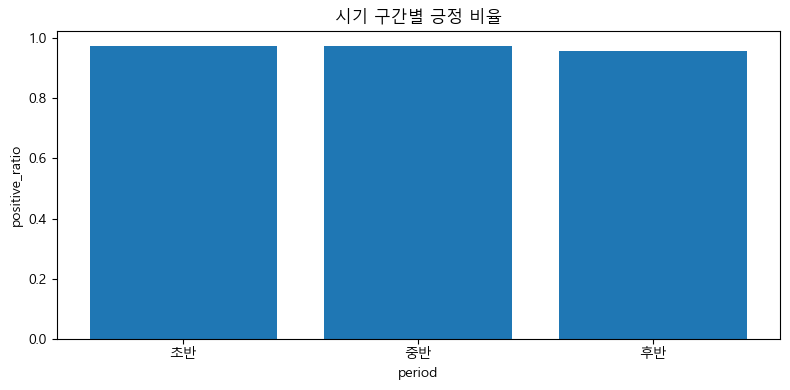

In [13]:
plt.figure(figsize=(8, 4))
plt.bar(period_summary["period"].astype(str), period_summary["positive_ratio"])
plt.title("시기 구간별 긍정 비율")
plt.xlabel("period")
plt.ylabel("positive_ratio")
save_current_figure("refined_positive_ratio_by_period.png")
plt.show()
plt.close()

저장 완료: C:\Users\USER\Desktop\cgv_review_project\outputs\figures\refined_avg_review_length_by_period.png


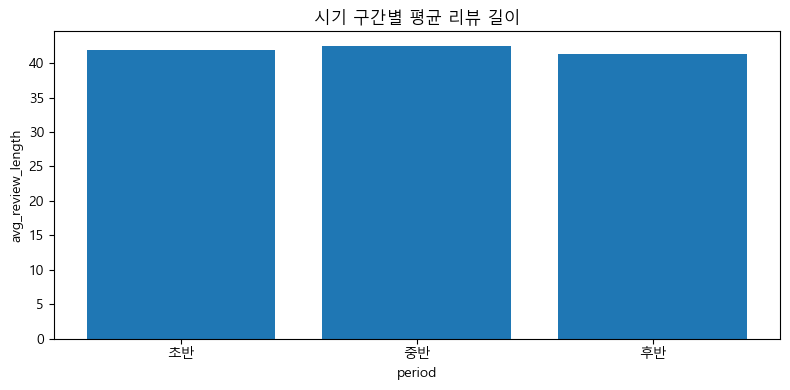

In [14]:
plt.figure(figsize=(8, 4))
plt.bar(period_summary["period"].astype(str), period_summary["avg_review_length"])
plt.title("시기 구간별 평균 리뷰 길이")
plt.xlabel("period")
plt.ylabel("avg_review_length")
save_current_figure("refined_avg_review_length_by_period.png")
plt.show()
plt.close()

## 8. refined 단어 빈도 분석

이제 refined 전처리 결과와 길이 필터 적용 데이터를 바탕으로  
단어 빈도 분석을 다시 수행한다.

이번에는 baseline보다 다음이 개선되었는지 확인하는 것이 중요하다.

- 비슷한 활용형이 하나의 단어로 더 잘 모였는가
- 불필요한 상투 표현이 줄었는가
- 키워드의 주제 응집력이 높아졌는가

In [15]:
def tokenize_for_freq(text: str, stopwords: set[str]) -> list[str]:
    tokens = text.split()
    tokens = [tok for tok in tokens if tok not in stopwords and len(tok) >= 2]
    return tokens


all_tokens_refined = []
for text in df_text_sub["review_normalized_refined"]:
    all_tokens_refined.extend(tokenize_for_freq(text, stopwords))

token_counter_refined = Counter(all_tokens_refined)
top_keywords_refined = pd.DataFrame(token_counter_refined.most_common(30), columns=["keyword", "count"])

top_keywords_refined.head(20)

,keyword,count
0,연기,10705
1,배우,8296
2,유해진,3470
3,박지훈,2964
4,눈물,2945
5,봤습니다,2518
6,오랜만에,2295
7,단종의,1851
8,단종,1643
9,좋았습니다,1537


저장 완료: C:\Users\USER\Desktop\cgv_review_project\outputs\figures\refined_top_keywords_bar.png


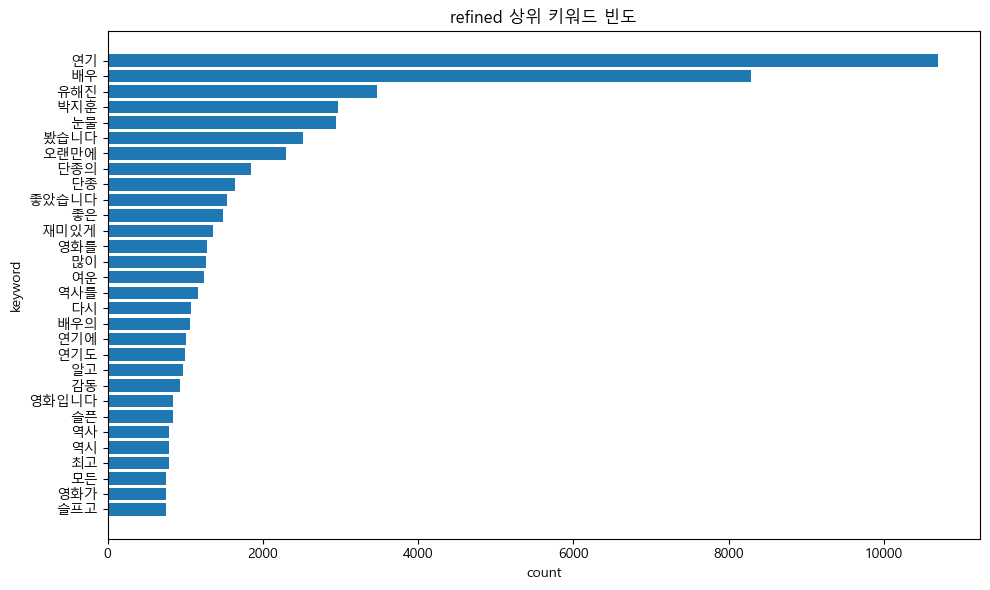

In [16]:
plt.figure(figsize=(10, 6))
plt.barh(top_keywords_refined["keyword"][::-1], top_keywords_refined["count"][::-1])
plt.title("refined 상위 키워드 빈도")
plt.xlabel("count")
plt.ylabel("keyword")
save_current_figure("refined_top_keywords_bar.png")
plt.show()
plt.close()

## 9. refined TF-IDF 분석

TF-IDF는 말뭉치 전체에서 자주 등장하지만  
모든 문서에 동일하게 퍼진 단어보다,  
상대적으로 특징적인 단어를 강조하는 데 유용하다.

여기서는 refined 텍스트와 길이 필터 적용 서브셋을 기준으로  
상위 TF-IDF 단어를 다시 확인한다.

In [17]:
tfidf_vectorizer_refined = TfidfVectorizer(
    max_features=1000,
    stop_words=list(stopwords),
    ngram_range=(1, 1),
    min_df=3,
)

tfidf_matrix_refined = tfidf_vectorizer_refined.fit_transform(df_text_sub["review_normalized_refined"])
feature_names_refined = tfidf_vectorizer_refined.get_feature_names_out()
tfidf_scores_refined = np.asarray(tfidf_matrix_refined.mean(axis=0)).ravel()

tfidf_top_refined = (
    pd.DataFrame({
        "term": feature_names_refined,
        "tfidf_mean": tfidf_scores_refined
    })
    .sort_values("tfidf_mean", ascending=False)
    .reset_index(drop=True)
)

tfidf_top_refined.head(30)

,term,tfidf_mean
0,연기,0.056415
1,배우,0.045881
2,유해진,0.023791
3,봤습니다,0.023586
4,박지훈,0.020086
5,눈물,0.019735
6,오랜만에,0.017276
7,재미있게,0.015074
8,단종,0.013417
9,좋았습니다,0.013183


저장 완료: C:\Users\USER\Desktop\cgv_review_project\outputs\figures\refined_top_tfidf_terms.png


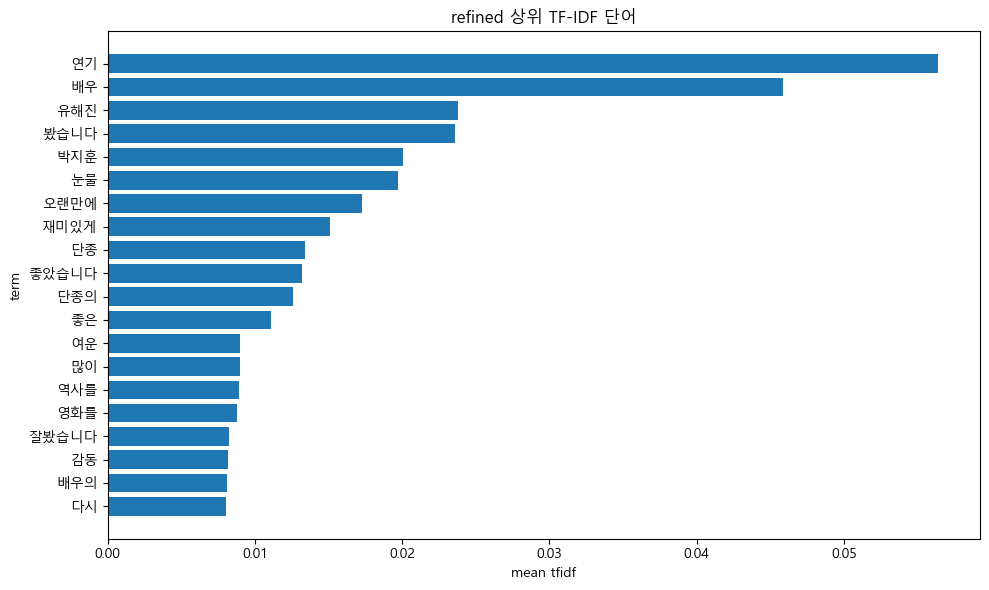

In [18]:
plt.figure(figsize=(10, 6))
top_tfidf_plot_refined = tfidf_top_refined.head(20).sort_values("tfidf_mean", ascending=True)
plt.barh(top_tfidf_plot_refined["term"], top_tfidf_plot_refined["tfidf_mean"])
plt.title("refined 상위 TF-IDF 단어")
plt.xlabel("mean tfidf")
plt.ylabel("term")
save_current_figure("refined_top_tfidf_terms.png")
plt.show()
plt.close()

## 10. refined n-gram 분석

이번에는 refined 텍스트를 기준으로 bigram과 trigram을 다시 본다.

특히 baseline에서 확인된 핵심 주제:

- 배우 연기
- 특정 배우 언급
- 감정적 여운
- 몰입감

이 refined 결과에서도 보다 선명하게 나타나는지 확인한다.

In [19]:
bigram_vectorizer_refined = CountVectorizer(
    max_features=500,
    stop_words=list(stopwords),
    ngram_range=(2, 2),
    min_df=3
)

bigram_matrix_refined = bigram_vectorizer_refined.fit_transform(df_text_sub["review_normalized_refined"])
bigram_counts_refined = np.asarray(bigram_matrix_refined.sum(axis=0)).ravel()
bigram_terms_refined = bigram_vectorizer_refined.get_feature_names_out()

bigrams_df_refined = (
    pd.DataFrame({
        "bigram": bigram_terms_refined,
        "count": bigram_counts_refined
    })
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

bigrams_df_refined.head(30)

,bigram,count
0,배우 연기,3883
1,유해진 배우,612
2,왕과 사는,536
3,박지훈 배우,519
4,사는 남자,477
5,유해진 연기,474
6,배우 연기도,437
7,연기 좋았습니다,412
8,재미있게 봤습니다,411
9,배우분들 연기,366


저장 완료: C:\Users\USER\Desktop\cgv_review_project\outputs\figures\refined_bigram_bar.png


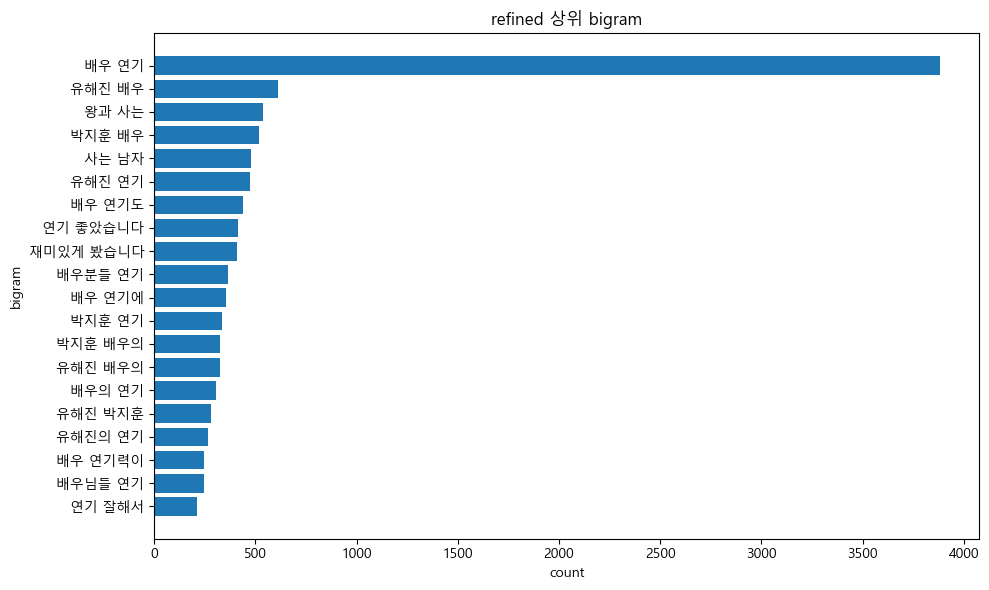

In [20]:
plt.figure(figsize=(10, 6))
bigram_plot_refined = bigrams_df_refined.head(20).sort_values("count", ascending=True)
plt.barh(bigram_plot_refined["bigram"], bigram_plot_refined["count"])
plt.title("refined 상위 bigram")
plt.xlabel("count")
plt.ylabel("bigram")
save_current_figure("refined_bigram_bar.png")
plt.show()
plt.close()

In [21]:
trigram_vectorizer_refined = CountVectorizer(
    max_features=300,
    stop_words=list(stopwords),
    ngram_range=(3, 3),
    min_df=3
)

trigram_matrix_refined = trigram_vectorizer_refined.fit_transform(df_text_sub["review_normalized_refined"])
trigram_counts_refined = np.asarray(trigram_matrix_refined.sum(axis=0)).ravel()
trigram_terms_refined = trigram_vectorizer_refined.get_feature_names_out()

trigrams_df_refined = (
    pd.DataFrame({
        "trigram": trigram_terms_refined,
        "count": trigram_counts_refined
    })
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

trigrams_df_refined.head(20)

,trigram,count
0,왕과 사는 남자,462
1,유해진 배우 연기,221
2,배우 연기 좋았습니다,220
3,박지훈 배우 연기,121
4,배우 연기 좋아서,105
5,모든 배우 연기,105
6,배우 연기 좋아요,104
7,시간 가는줄 모르고,102
8,유해진 배우의 연기,102
9,시간 가는 모르고,87


## 11. 긍정/부정 키워드 refined 재비교

baseline에서도 긍정/부정 리뷰의 차이는 분명했지만,  
이번에는 refined 정제 결과를 기준으로 다시 비교한다.

관심 포인트는 다음과 같다.

- 긍정 리뷰에서 반복적으로 나타나는 배우/감정 중심 표현
- 부정 리뷰에서 반복적으로 나타나는 스토리/연출/기대 관련 표현
- refined 처리 이후 차이가 더 선명해졌는가

In [22]:
positive_df_refined = df_text_sub[df_text_sub["score"] == 2].copy()
negative_df_refined = df_text_sub[df_text_sub["score"] == 1].copy()

print("positive_df_refined:", positive_df_refined.shape)
print("negative_df_refined:", negative_df_refined.shape)

positive_df_refined: (45080, 30)
negative_df_refined: (1330, 30)


In [23]:
def get_top_tokens_from_series(series: pd.Series, stopwords: set[str], top_n: int = 30) -> pd.DataFrame:
    tokens = []
    for text in series:
        tokens.extend(tokenize_for_freq(text, stopwords))
    counter = Counter(tokens)
    return pd.DataFrame(counter.most_common(top_n), columns=["keyword", "count"])

positive_top_refined = get_top_tokens_from_series(
    positive_df_refined["review_normalized_refined"], stopwords, top_n=30
)

negative_top_refined = get_top_tokens_from_series(
    negative_df_refined["review_normalized_refined"], stopwords, top_n=30
)

print("[긍정 리뷰 상위 단어 - refined]")
display(positive_top_refined)

print("[부정 리뷰 상위 단어 - refined]")
display(negative_top_refined)

[긍정 리뷰 상위 단어 - refined]


,keyword,count
0,연기,10450
1,배우,8117
2,유해진,3382
3,박지훈,2942
4,눈물,2922
5,봤습니다,2510
6,오랜만에,2286
7,단종의,1828
8,단종,1621
9,좋았습니다,1530


[부정 리뷰 상위 단어 - refined]


,keyword,count
0,연기,255
1,배우,179
2,유해진,88
3,연출,66
4,많이,59
5,영화가,51
6,스토리,50
7,연출이,45
8,좋은,40
9,이게,39


## 12. 시기 구간별 상위 키워드 비교

후반부 긍정 비율 하락과 관련하여,  
시기 구간별로 어떤 단어가 반복적으로 등장하는지 확인한다.

이 단계는 “후반부에 무엇이 달라졌는가”를  
수치뿐 아니라 텍스트 차원에서 살펴보기 위한 보완 분석이다.

In [24]:
def get_period_top_keywords(df: pd.DataFrame, period_name: str, text_col: str, stopwords: set[str], top_n: int = 20) -> pd.DataFrame:
    sub = df[df["period"] == period_name].copy()
    tokens = []
    for text in sub[text_col]:
        tokens.extend(tokenize_for_freq(text, stopwords))
    counter = Counter(tokens)
    result = pd.DataFrame(counter.most_common(top_n), columns=["keyword", "count"])
    result.insert(0, "period", period_name)
    return result

period_keyword_frames = []
for period_name in ["초반", "중반", "후반"]:
    period_keyword_frames.append(
        get_period_top_keywords(
            df_text_sub, period_name, "review_normalized_refined", stopwords, top_n=20
        )
    )

period_keywords_refined = pd.concat(period_keyword_frames, ignore_index=True)
period_keywords_refined.head(30)

,period,keyword,count
0,초반,연기,5263
1,초반,배우,4002
2,초반,유해진,1724
3,초반,박지훈,1496
4,초반,눈물,1261
5,초반,봤습니다,1189
6,초반,오랜만에,950
7,초반,단종의,876
8,초반,단종,779
9,초반,좋은,742


In [25]:
for period_name in ["초반", "중반", "후반"]:
    print(f"\n[{period_name} 상위 키워드]")
    display(period_keywords_refined[period_keywords_refined["period"] == period_name].reset_index(drop=True))


[초반 상위 키워드]


,period,keyword,count
0,초반,연기,5263
1,초반,배우,4002
2,초반,유해진,1724
3,초반,박지훈,1496
4,초반,눈물,1261
5,초반,봤습니다,1189
6,초반,오랜만에,950
7,초반,단종의,876
8,초반,단종,779
9,초반,좋은,742



[중반 상위 키워드]


,period,keyword,count
0,중반,연기,4078
1,중반,배우,3253
2,중반,유해진,1323
3,중반,눈물,1264
4,중반,박지훈,1160
5,중반,오랜만에,1035
6,중반,봤습니다,1003
7,중반,단종의,744
8,중반,단종,686
9,중반,좋았습니다,622



[후반 상위 키워드]


,period,keyword,count
0,후반,연기,1364
1,후반,배우,1040
2,후반,유해진,423
3,후반,눈물,420
4,후반,봤습니다,326
5,후반,오랜만에,310
6,후반,박지훈,308
7,후반,단종의,231
8,후반,좋았습니다,199
9,후반,많이,199


## 13. 이미지 포함 여부 refined 재확인

이미지 포함 리뷰는 전체 비중이 작지만,  
refined 분석에서도 길이와 긍정 비율 차이를 다시 간단히 확인한다.

이는 exploratory 수준의 비교이며,  
표본 수 차이를 감안해 해석은 조심스럽게 유지한다.

In [26]:
image_compare_refined = (
    df_text_sub.groupby("has_image", as_index=False)
    .agg(
        review_count=("review_id", "count"),
        positive_ratio=("is_positive", "mean"),
        avg_review_length=("review_length", "mean"),
        median_review_length=("review_length", "median"),
        avg_like_count=("like_count", "mean"),
        median_like_count=("like_count", "median"),
    )
)

image_compare_refined

,has_image,review_count,positive_ratio,avg_review_length,median_review_length,avg_like_count,median_like_count
0,N,45921,0.971103,41.966312,31.0,0.355545,0.0
1,Y,489,0.993865,60.527607,55.0,0.400818,0.0


## 14. 샘플 기반 토픽 탐색 보완

refined 버전에서는 다음 샘플을 다시 확인한다.

- 초반 대표 리뷰
- 후반 대표 리뷰
- 부정 리뷰 중 길이가 긴 샘플
- 긍정 리뷰 중 길이가 긴 샘플

이 과정을 통해 구간별/감성별로 어떤 서술 차이가 있는지  
더 구체적으로 읽어볼 수 있다.

In [27]:
early_samples = (
    df_text_sub[df_text_sub["period"] == "초반"]
    [["review_date", "sentiment_label", "review_length", "review"]]
    .sample(min(10, len(df_text_sub[df_text_sub["period"] == "초반"])), random_state=42)
    .reset_index(drop=True)
)

late_samples = (
    df_text_sub[df_text_sub["period"] == "후반"]
    [["review_date", "sentiment_label", "review_length", "review"]]
    .sample(min(10, len(df_text_sub[df_text_sub["period"] == "후반"])), random_state=42)
    .reset_index(drop=True)
)

print("[초반 샘플]")
display(early_samples)

print("[후반 샘플]")
display(late_samples)

[초반 샘플]


,review_date,sentiment_label,review_length,review
0,2026-02-10,좋았어요,50,역사적으로 있었던일이기에 더 가슴아프고 배우들의 연기때문에 더 몰입하며 볼수있었어요!!👍
1,2026-02-11,좋았어요,64,오랜만에 보는 사극입니다. 단종과 세조에 대한 역사적 사실을 계속 찾아 보게 되네요. 좋은 경험입니다. 감사합니다.
2,2026-02-08,좋았어요,26,유해진배우와 모든 배우들 연기가 너무 좋았어요~
3,2026-02-15,좋았어요,46,역사를 다시한번 찾아보게 되고\n단종에 대해서 다시금 생각해 보는 기회가 됭ㆍㅆ어요
4,2026-02-09,좋았어요,64,그저 이렇게라도 단종의 한을 풀 수만 있다면 그것만으로 만족할 수 있는 영화\n존귀한 단종을 볼 수 있어서 좋았습니다
5,2026-02-18,좋았어요,22,배우들의 연기도 좋아 몰입이 잘되엇습니다
6,2026-02-16,좋았어요,108,박지훈 배우는 그야말로 단종 그 자체입니다.진짜 눈빛부터 걸음 하나하나가 이홍위였습니다.엄흥도와 매화와의 관계와 사육신과 생육신과의 관계도 애절했습니다.영화 내내 웃음포인토와 연출도 최고였습니다
7,2026-02-08,좋았어요,17,보길 잘했어요 이런 영화 좋아요
8,2026-02-18,좋았어요,25,실화에 몰입되어서 단종 모습이 너무 가슴아팠다
9,2026-02-10,별로예요,12,소문난 잔치…………..


[후반 샘플]


,review_date,sentiment_label,review_length,review
0,2026-03-29,좋았어요,24,오래간만에 감동적인 영화를 극장에서 봤네요.
1,2026-03-14,좋았어요,82,"역사를 그린 영화가 너무 깊으면 진부할수 있는데, 가볍게 찰나처럼 에피소드로 그때를 그린 시각이 나머지는 관객이 느끼고 해석하는것 같아 좋았습니다."
2,2026-03-12,좋았어요,14,많이 많이 많이 많이 많이
3,2026-03-14,좋았어요,30,왜 보면서 그냥 눈물이 나는지 직접 경험해 봐야함\n감동
4,2026-03-22,좋았어요,13,감동의 도가니탕이었습니다
5,2026-03-11,좋았어요,15,아주 재미있게 잘 봤습니다.
6,2026-03-20,좋았어요,107,박지훈의 눈빛때문에 영화시작부터 눈물이 났습니다.\n실화바탕의 내용이라 더 와닿았고 배우들의 연기가 몰입도를 최대로 끌어올려 최고의 영화를 만들어낸것 같습니다. \n오랜만에 영화 너무 잘 봤습니다
7,2026-03-22,좋았어요,83,누군가가 500년 만에 단종의 장례를 치른것 같다고했다. 영화만큼 감동스러운 감상평이었다.\n애민정신으로 백성을 궁휼히 여긴 단종왕이시여 편히 잠드소서
8,2026-03-14,좋았어요,22,배우들 연기도 좋았고 너무 재밌게 봤어요
9,2026-03-19,좋았어요,54,역사물은 거의 무거운 느낌이지만 이영화는 재미 코믹스러운 면도 있고 마지막 부분에서는 감동적이었다


In [28]:
negative_long_samples = (
    negative_df_refined.sort_values("review_length", ascending=False)
    [["review_date", "like_count", "review_length", "review"]]
    .head(15)
    .reset_index(drop=True)
)

positive_long_samples = (
    positive_df_refined.sort_values("review_length", ascending=False)
    [["review_date", "like_count", "review_length", "review"]]
    .head(15)
    .reset_index(drop=True)
)

print("[부정 장문 샘플]")
display(negative_long_samples)

print("[긍정 장문 샘플]")
display(positive_long_samples)

[부정 장문 샘플]


,review_date,like_count,review_length,review
0,2026-03-24,2,145,영화를 보는 내내 &lt;해적:바다로 간 산적&gt;의 &lt;철봉&gt;이와 &lt;달짝지근해&gt;의 &lt;치호&gt;가 &lt;엄흥도&gt;를 연기한 그냥 유해진 배우의 전형적인 말장난으로 가득한 재미도 메세지도 없는 억지 코미디 영화였다고 생각됩니다.
1,2026-03-15,3,127,"도대체 어떻게 1000만 갔는지 이해가 안되는 영화,, 호랑이 CG빼고는 불만이 없다는게 이해가 안되는 영화,, 오히려 호랑이 CG는 봐줄만 했을 정도,,스토리, 배우들 연기 다 1000만 영화급이 아닌데도 1000만간게 용함."
2,2026-03-01,0,126,"강남 3/1 9:30 영화 10:20부터 10:28 까지 화면 안나옴..\n\n사실 영화는 넘 좋아서 어제 보고 오늘 친구랑 다시 본 건데..\n이런 상영경험은 처음이었어요.\n\n배우님과 내용이 좋지 않았더라면, 많이 화가 났겠지요?"
3,2026-03-21,9,125,아.. 너무 실망스러움. 이게 왜 천만을 넘은거지...?\n\n말도 안되는 유치한 꽁트코메디로 가다가. 어거지 신파로 마무리. 연출.연기.대사 전부 진부하고 촌스러움. CG는 쓰레기. 이게 왜..? 내가 이상한건가..? 생각함
4,2026-03-02,2,122,"주제 10점. 연기 10점. 연출 5점 평타 수준입니다.\n경쟁작 전무, 각종 제휴로 관람료 할인 등 상황을 고려해도 2-3백만명이 적당함.\n유해진의 맨 파워와 마지막 신파(단종과 궁녀 자살) 입소문이 대흥행 이유인듯!"
5,2026-02-15,1,120,25~26년 실관람중 최하.\n유해진 배우의 원맨쇼 4~5씬 빼면 너무 지루하고 재미없음. 남자들은 완전 비추.\n끝나고나오는 길에 대체로 남자들은 툴툴거림. \n넷플이없으면 30분보다가 끔(지극히 개인적인 평입니다)
6,2026-03-21,5,119,"1000만 영화다고 보면 실망이 클수있음.\n400~500만 정도느낌.. 호랑이cg 나올때 부터 실망, 하지만 유지태씨와 시중역활 여성분 연기 칭찬합니다. 유해진씨는 짐작했던 연기.. 장항준씨가 천재는 아님을 확인함"
7,2026-02-19,1,118,"새삼 광해가 얼마나 잘 만든 영화인지, 이병헌이 얼마나 연기를 잘 했는지 다시한번 깨닫는 시간이었습니다. 영화 연출을 뭐 80~90년대 감성으로 유치하게 찍어서 보는 맛이 없었고, 연기도 좋지는 않네요. 돈 아깝"
8,2026-02-22,0,118,500만 돌파했다고 해서 오랜만에 극장 갔는데 기대했던거 보다 별로였어요. 유튜브 짤에 낚였네요. 돈 아까워요. 극장까지 가서 볼 정도는 아닌거 같아요. 스토리와 연출이 너무 단조로워요. 배우들 연기는 Good!
9,2026-02-25,1,118,어떻게 이게 평점이 좋을수 있지.. 스토리는 분명히 초등학생이 썼거나 쓰다 만거 같아요.. 좋은 이야기를 망한 스토리로 각본한 영화네요. 배우 연기만 잘했는데.. 배우 대사도 얼척 없고.. 수준이 너무 낮아요..


[긍정 장문 샘플]


,review_date,like_count,review_length,review
0,2026-03-05,1,135,이홍위 밥 먹어...이홍위 밥 먹어...이홍위 밥 먹어...\n이홍위 밥 먹어...이홍위 밥 먹어...이홍위 밥 먹어...\n이홍위 밥 먹어...이홍위 밥 먹어...이홍위 밥 먹어...\n이홍위 밥 먹어...이홍위 밥 먹어...이홍위 밥 먹어...
1,2026-02-16,0,130,범계 CGV 2월 16일 12:35타임 B열 7-10\n진짜 뒤진다 \n과자를 시댕 부스럭 부스럭 거리면서 30분 내내 처먹네 하 ㅋ\nㅋ\n영화 중간에 일어나질 않나ㅋㅋ \n가족 단위로 왔으면 제발 점잖게 좀 보고 그러자 기본이 안 돼있네;
2,2026-02-21,2,127,유해진 배우 연기는 말 할 것도 없죠..날라다니고..!! 무엇보다 박지훈 배우!! 처연함 속에 강인함을.. 너무 잘 표현한 것 같아요.. 눈이.. 웃고있는데 울고있어요.. oh God 그럼 나는 네.. 울게요..하고 우는거에요😭
3,2026-03-08,0,127,"와.. ㅎㅎ 매력포인트 /감정포인트 너무 …. 몰빵 ..\n이해해요 ㅎㅎ 장감독님~ 정말 영화 잘 만드셨어요!\n막 안타까워 하면서 봤네요..!!!\n간만에,. 온가족과 함께 영화봄!! \n(초5 이하는! 체험이 있어서~ 겸사겸사!!)"
4,2026-02-07,0,126,"유해진의 조선시대 유니버스 완성작\n해적(태조) &gt; 왕과 사는 남자(단종) &gt; 왕의 남자(연산군) &gt; 전우치(중종) &gt; 혈의 누(순조) &gt; 올빼미(인조) \n이후 봉오동전투, 말모이로 이어지는데...."
5,2026-02-11,0,125,"월요병 도진 진짜 진짜 근무하기 싫은 날..\n아이는 학원을 가서 늦게 오고,\n남편은 약속이 있어서 늦게 오는 날..\n좋아! 영화나 보자~ 싶어 \n아무런 기대, 정보 없이 본 영화..\n\n엉엉~ 펑펑 울고, 가슴 먹먹해진 날!!"
6,2026-03-03,1,125,"스토리나 연기가 아쉬운 부분이 있지만 유해진이 다 살림. 엄홍도 그 자체!\n중계 11시 7관 J10,11 큰소리 대화+휴대폰 불빛, 그 왼쪽은 상영 시작 후 20분 내내 시끄러움. 비닐 소리가 민폐인지 모름. 배려는 지능문제"
7,2026-03-09,0,125,장항준 : 울어라!!!!\n나 : 네!!!!\n\n지훈님 눈빛 연기가 너무 좋았어요.... 눈빛만으로도 뭘 말하고 싶은지 알 수 있었습니다... 유해진님 엄흥도 연기 때문에 마지막에 엉엉 울다가 휴지 눈에 붙이고 봣네요....ㅠㅠ
8,2026-02-18,0,124,처음에 슬프게 시작하다가 유해진배우가 나오자마자 영화가 코믹 으로 흐르다가 두배우 만나서 잔잔 하게 흐르다가 \n\n\n너무 슬펐어요 실화라 더 안타깝고 성인도 안되는 시기에 ㅜㅜ
9,2026-02-11,2,124,정말 웃고 울며 본 영화~!!! 배우들의 연기도 너무 좋았고 눈물나게하는 스토리까지...!!!\n아이들과 다시 한번 더 보고싶은 영화~!!!\n컨디션 바닥인데 영화보고나니 정말 아픈게 싹 나은 느낌~~!!!\n재미와 감동 다잡음


## 15. baseline vs refined 핵심 비교 요약

이 단계에서는 refined 분석 결과를 baseline과 비교해  
무엇이 개선되었는지 정리한다.

주요 비교 포인트는 다음과 같다.

- 상위 키워드의 응집도
- 활용형 통합 여부
- 노이즈 감소 여부
- 구간 비교 가능성
- 짧은 리뷰 제외에 따른 해석력 향상

정량적 비교가 목적이라기보다,  
결과 해석의 선명도가 얼마나 좋아졌는지를 확인하는 것이 핵심이다.

In [29]:
baseline_vs_refined_summary = pd.DataFrame({
    "item": [
        "text_normalization",
        "html_escape_cleaning",
        "replacement_rules",
        "short_review_filter",
        "period_comparison",
        "keyword_interpretability",
    ],
    "baseline": [
        "기본 정규화",
        "미반영",
        "미반영",
        "미반영",
        "부분적",
        "보통",
    ],
    "refined": [
        "정규화 + html 해제 + 반복문자 정리",
        "반영",
        "반영",
        f"review_length >= {MIN_REVIEW_LENGTH}",
        "초반/중반/후반 비교",
        "향상",
    ]
})

baseline_vs_refined_summary

,item,baseline,refined
0,text_normalization,기본 정규화,정규화 + html 해제 + 반복문자 정리
1,html_escape_cleaning,미반영,반영
2,replacement_rules,미반영,반영
3,short_review_filter,미반영,review_length >= 10
4,period_comparison,부분적,초반/중반/후반 비교
5,keyword_interpretability,보통,향상


## 16. 결과 저장

refined 버전에서 생성한 주요 표와 그래프를 저장한다.  
이 결과는 이후 README 정리, 발표 자료 준비, Streamlit 앱 연결,  
그리고 최종 BERTopic 해석의 기초 자료로 활용할 수 있다.

In [30]:
top_keywords_refined.to_csv(TABLE_DIR / "refined_top_keywords.csv", index=False, encoding="utf-8-sig")
tfidf_top_refined.to_csv(TABLE_DIR / "refined_top_tfidf_terms.csv", index=False, encoding="utf-8-sig")
bigrams_df_refined.to_csv(TABLE_DIR / "refined_bigrams.csv", index=False, encoding="utf-8-sig")
trigrams_df_refined.to_csv(TABLE_DIR / "refined_trigrams.csv", index=False, encoding="utf-8-sig")
period_summary.to_csv(TABLE_DIR / "refined_period_summary.csv", index=False, encoding="utf-8-sig")
period_keywords_refined.to_csv(TABLE_DIR / "refined_period_keywords.csv", index=False, encoding="utf-8-sig")
image_compare_refined.to_csv(TABLE_DIR / "refined_image_compare.csv", index=False, encoding="utf-8-sig")
positive_top_refined.to_csv(TABLE_DIR / "refined_positive_top_keywords.csv", index=False, encoding="utf-8-sig")
negative_top_refined.to_csv(TABLE_DIR / "refined_negative_top_keywords.csv", index=False, encoding="utf-8-sig")
early_samples.to_csv(TABLE_DIR / "refined_early_samples.csv", index=False, encoding="utf-8-sig")
late_samples.to_csv(TABLE_DIR / "refined_late_samples.csv", index=False, encoding="utf-8-sig")
negative_long_samples.to_csv(TABLE_DIR / "refined_negative_long_samples.csv", index=False, encoding="utf-8-sig")
positive_long_samples.to_csv(TABLE_DIR / "refined_positive_long_samples.csv", index=False, encoding="utf-8-sig")
baseline_vs_refined_summary.to_csv(TABLE_DIR / "baseline_vs_refined_summary.csv", index=False, encoding="utf-8-sig")

print("refined 결과 저장 완료")

refined 결과 저장 완료


## 17. refined 단계 정리

이번 refined 분석에서는 baseline의 전체 흐름을 유지하면서도,  
텍스트 정제와 해석력을 높이기 위한 보완을 수행하였다.

주요 개선점은 다음과 같다.

- HTML escape, 줄바꿈, 반복문자 정리
- 활용형과 조사 결합형 일부 통합
- 불용어 보완
- 짧은 리뷰 제외 버전 분석 추가
- 시기 구간(초반/중반/후반) 비교 추가
- refined 키워드 / TF-IDF / n-gram 재도출
- 긍정/부정 리뷰 차이 재확인

이 결과는 이후 최종 데이터 수집 완료 후  
`03_bertopic.ipynb`에서 본격적인 토픽 모델링을 수행할 때  
전처리 전략과 해석 기준을 제공하는 중간 단계 역할을 한다.

즉, refined 단계는 단순한 추가 분석이 아니라,  
**BERTopic 이전에 텍스트 품질과 해석 가능성을 끌어올리는 준비 단계**라고 볼 수 있다.

## 18. refined 결과 해석

이번 refined 분석은 baseline 결과를 바탕으로 텍스트 정제 수준을 높이고,  
짧은 리뷰 제외 및 시기 구간 비교를 추가하여 해석력을 보완하는 데 목적이 있었다.  
즉, baseline이 전체 흐름을 빠르게 파악하는 기초 EDA였다면, refined는 그 결과를 더 선명하게 읽기 위한 보완 단계라고 할 수 있다.

가장 먼저 확인되는 점은, refined 분석에서도 이 영화에 대한 관객 반응의 기본 방향은 여전히 **매우 강한 호평**이라는 사실이다. 시기 구간별 긍정 비율을 보면 초반과 중반은 거의 비슷한 높은 수준을 유지하고, 후반부에서만 소폭 하락하는 양상이 나타난다. 하지만 후반부 역시 긍정 비율 자체는 여전히 매우 높은 수준에 머물러 있다. 따라서 이 변화는 작품에 대한 평가가 부정적으로 전환되었다기보다, 흥행 확산 이후 관객 구성이 조금 더 넓어지면서 평가가 다소 분화된 결과로 해석하는 것이 적절하다. 다시 말해, 초반에는 작품 성격이나 배우 조합에 호응하는 관객이 먼저 반응했고, 후반에는 화제성이나 흥행 성과를 보고 유입된 관객들 사이에서 기대 대비 아쉬움이 일부 드러났을 가능성이 있다.

시기 구간별 평균 리뷰 길이를 보면 초반, 중반, 후반 모두 큰 차이 없이 40자 안팎의 수준을 유지하고 있다. 이는 후반부 긍정 비율 하락이 단순히 짧고 성의 없는 부정 리뷰 증가로 설명되지는 않는다는 점을 보여준다. 오히려 후기 구간에서도 리뷰 작성의 밀도 자체는 유지된 상태에서, 평가 방향이 조금 더 다양해졌다고 보는 편이 타당하다. 즉, 리뷰 수는 감소하더라도 리뷰의 서술 밀도는 크게 무너지지 않았으며, 이는 후반부의 부정적 반응도 일정 정도 의미를 가진 관람 경험의 표현으로 볼 수 있음을 시사한다.

텍스트 정제 결과를 반영한 refined 상위 키워드 빈도는 baseline보다 훨씬 응집된 패턴을 보여준다. 특히 `연기`, `배우`, `유해진`, `박지훈`, `눈물`과 같은 단어가 중심에 놓여 있으며, 이는 이 영화에 대한 관객 반응의 핵심 축이 여전히 **배우 연기와 감정적 반응**에 있음을 다시 확인시켜준다. baseline에서는 `연기`, `연기가`, `연기는`처럼 유사한 표현이 분리되어 나타났지만, refined에서는 이러한 변형이 일정 부분 통합되면서 중심 단어가 더 선명하게 드러났다. 이는 텍스트 정제의 효과가 실제 분석 결과에도 반영되었음을 의미한다.

refined TF-IDF 결과 역시 같은 방향을 보여준다. `연기`, `배우`, `유해진`, `박지훈`, `눈물`, `여운`, `감동` 등의 단어가 상대적으로 높은 중요도를 가지며 나타난다는 점은, 관객들이 이 작품을 단순히 줄거리 중심으로 소비한 것이 아니라 **배우의 연기력, 감정적 몰입, 그리고 관람 후 남는 여운**을 중심으로 기억하고 있음을 시사한다. 즉, 이 영화는 사건 전개 자체보다도 “누가 어떻게 연기했는가”, “어떤 감정을 남겼는가”의 차원에서 강하게 수용된 것으로 볼 수 있다.

refined bigram 결과는 이러한 해석을 더 구체적으로 뒷받침한다. `배우 연기`가 압도적으로 높은 빈도로 나타났고, `유해진 배우`, `박지훈 배우`, `유해진 연기`, `배우 연기도`, `연기 좋았습니다`, `재미있게 봤습니다` 등의 표현이 뒤를 잇는다. 이는 관객들의 서술이 단순히 “재밌다” 수준에 머무르지 않고, 배우 개인과 연기력 평가를 중심으로 조직되고 있음을 보여준다. 또한 `왕과 사는`, `사는 남자`와 같은 표현이 함께 나타나는 것은 작품명이 리뷰 속에서 직접적으로 반복되면서, 영화 자체의 존재감도 분명하게 유지되고 있음을 뜻한다. 즉, refined bigram은 이 영화 리뷰의 핵심 문맥이 **작품명 + 배우 + 연기 평가**라는 구조로 이루어져 있음을 드러낸다.

이러한 결과를 종합하면, refined 분석에서 가장 강하게 드러나는 서사는 다음과 같다.  
첫째, 이 영화는 전반적으로 매우 높은 수준의 긍정 평가를 받았다.  
둘째, 그 긍정 평가의 중심에는 배우의 연기력과 감정적 여운이 있었다.  
셋째, 후반부로 갈수록 긍정 비율은 소폭 낮아졌지만, 이는 기본 호평 기조를 흔들 정도는 아니며, 오히려 흥행 후반부 관객층의 다양화에 따른 기대 대비 반응 차이로 볼 수 있다.

또한 refined 분석은 baseline에 비해 해석력을 높이는 데 실제로 기여했다. HTML escape 및 줄바꿈 제거, 반복문자 정리, 규칙 기반 치환, 불용어 보완, 그리고 길이 필터 적용을 통해 키워드와 n-gram이 더 응집된 형태로 나타났고, 그 결과 “배우 연기”, “특정 배우 언급”, “감정적 반응”이라는 주요 축이 보다 명확하게 드러났다. 이는 이후 BERTopic과 같은 본격적인 토픽 모델링을 수행할 때도 중요한 전처리 기준과 해석 기준이 될 수 있다.

정리하면, refined 단계는 baseline에서 확인한 핵심 메시지를 유지하면서도 그것을 더 선명하게 다듬는 역할을 했다. 이 영화는 CGV 리뷰 기준으로 매우 강한 호평을 받은 작품이며, 관객 반응의 중심은 배우 연기와 감정적 여운에 있었다. 동시에 후반부에는 기대 대비 아쉬움이 일부 드러나는 변화도 관찰되었다. 따라서 이 작품의 수용 양상은 단순한 “흥행작에 대한 일괄적 호평”이라기보다, **배우 중심의 감정적 호평을 기반으로 하되, 흥행 후반부에는 서사와 연출에 대한 평가가 조금씩 분화되는 구조**로 요약할 수 있다.

향후에는 최종 수집본 약 53,000여 건을 바탕으로 불용어 사전과 치환 규칙을 좀 더 고도화하고, 문장 임베딩 기반 BERTopic 분석을 수행함으로써 현재 확인된 핵심 축이 실제 토픽 단위로 어떻게 분리되는지 살펴볼 수 있다. 특히 refined 단계에서 확인된 `배우 연기`, `감정적 여운`, `기대 대비 아쉬움`이라는 세 축은 이후 고급 토픽 모델링의 유력한 해석 기준이 될 것이다.